# ABC/XYZ-анализ ассортимента

Исследование строится на данных за 2023 год `source_date` в границах года. ABC по выручке XYZ по стабильности спроса, объединённая матрица, проверка эластичности спроса к скидке. В `00_pygwalker_eda.ipynb`  показано что выручка по товарам распределена ближе к колоколообразной форме чем к длинному хвосту, поэтому классическая граница 80/20 здесь маловероятна, ниже считается фактическая граница.

In [1]:
import sys
for p in (".", ".."):
    if p not in sys.path:
        sys.path.insert(0, p)

import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

from scripts.common import config

engine = create_engine(
    f"postgresql+psycopg2://{config.POSTGRES_USER}:{config.POSTGRES_PASSWORD}"
    f"@{config.POSTGRES_HOST}:{config.POSTGRES_PORT}/{config.POSTGRES_DB}"
)

YEAR_START = "2023-01-01"
YEAR_END = "2024-01-01"

## ABC по выручке

Товары ранжируются по выручке за 2023 год и  считается накопленная доля выручки. 
Границы: A до 80% накопленной выручки, B до 95%, C — остаток.

In [2]:
df_products = pd.read_sql(
    f"""
    select product_id, sum(total_price) as total_revenue, sum(quantity) as total_quantity, count(*) as sales_count
    from staging.stg_sales
    where source_date >= '{YEAR_START}' and source_date < '{YEAR_END}'
    group by product_id
    """,
    engine,
)
df_products = df_products.sort_values("total_revenue", ascending=False).reset_index(drop=True)
df_products["cum_share"] = df_products["total_revenue"].cumsum() / df_products["total_revenue"].sum()
df_products["rank_share"] = (df_products.index + 1) / len(df_products)


def classify_abc(cum_share):
    if cum_share <= 0.8:
        return "A"
    elif cum_share <= 0.95:
        return "B"
    return "C"


df_products["abc"] = df_products["cum_share"].apply(classify_abc)
df_products["abc"].value_counts().reindex(["A", "B", "C"])

abc
A    26498
B    11748
C    11754
Name: count, dtype: int64

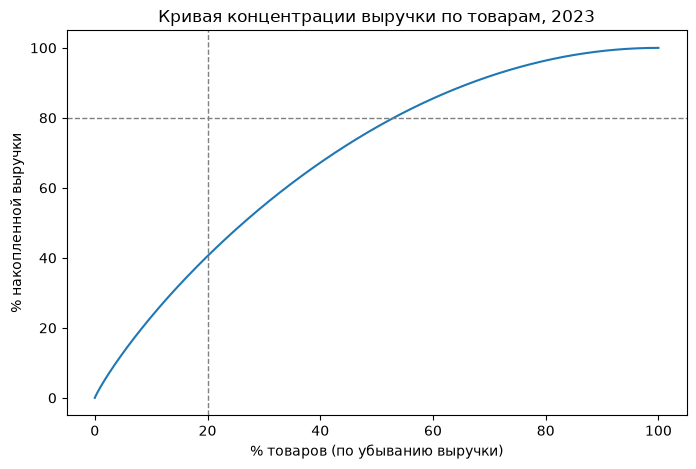

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_products["rank_share"] * 100, df_products["cum_share"] * 100)
ax.axhline(80, linewidth=1, linestyle="--", color="gray")
ax.axvline(20, linewidth=1, linestyle="--", color="gray")
ax.set_xlabel("% товаров (по убыванию выручки)")
ax.set_ylabel("% накопленной выручки")
ax.set_title("Кривая концентрации выручки по товарам, 2023")
plt.show()

Кривая без резкого изгиба в начале 20% товаров дающих 80% выручки отмечены пунктиром для сравнения, фактическая точка пересечения с линией 80% далеко правее. У большинства товаров вклад в выручку близкий, явных лидеров или аутсайдеров по деньгам мало. Группа A в такой сегментации выходит намного крупнее классической интерпритации, само деление на A/B/C  работает слабее чем в ритейле с выраженными хитами и аутсайдерами.

## XYZ по стабильности спроса

Коэффициент вариации месячного количества продаж на товар (`std/mean` по месяцам 2023 года). 

Границы: X до 10% Y до 25% Z — остальнйо.

In [4]:
monthly = pd.read_sql(
    f"""
    select
        product_id,
        date_trunc('month', source_date) as month,
        sum(quantity) as monthly_qty
    from staging.stg_sales
    where source_date >= '{YEAR_START}' and source_date < '{YEAR_END}'
    group by product_id, date_trunc('month', source_date)
    """,
    engine,
)
monthly.shape

(513079, 3)

In [5]:
stats = monthly.groupby("product_id")["monthly_qty"].agg(["mean", "std"]).fillna(0)
stats["cv"] = stats["std"] / stats["mean"]


def classify_xyz(cv):
    if cv <= 0.10:
        return "X"
    elif cv <= 0.25:
        return "Y"
    return "Z"


stats["xyz"] = stats["cv"].apply(classify_xyz)
stats["xyz"].value_counts().reindex(["X", "Y", "Z"])

xyz
X        NaN
Y       35.0
Z    49965.0
Name: count, dtype: float64

Почти весь ассортимент в Z, 35 товаров случайно попали в Y, X пусто. Причина в масштабе: за 2023 год 1.2 млн транзакций на 50 000 товаров, это около 2 транзакций на товар в месяц. При такой глубине выборки `std/mean` шумит независимо от того стабилен реальный спрос или нет. Проверка ниже, на квартальной группировке 2023 года, где транзакций на товар за период больше.

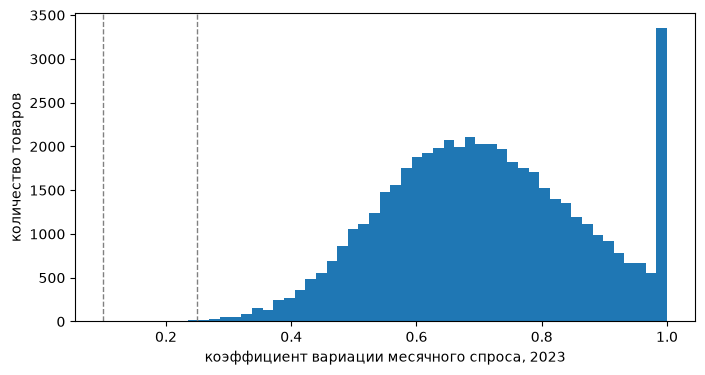

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(stats["cv"].clip(upper=1.0), bins=50)
ax.axvline(0.10, linewidth=1, linestyle="--", color="gray")
ax.axvline(0.25, linewidth=1, linestyle="--", color="gray")
ax.set_xlabel("коэффициент вариации месячного спроса, 2023")
ax.set_ylabel("количество товаров")
plt.show()

In [7]:
quarterly = pd.read_sql(
    f"""
    select
        product_id,
        date_trunc('quarter', source_date) as quarter,
        sum(quantity) as qty,
        count(*) as n_txn
    from staging.stg_sales
    where source_date >= '{YEAR_START}' and source_date < '{YEAR_END}'
    group by product_id, date_trunc('quarter', source_date)
    """,
    engine,
)
q_stats = quarterly.groupby("product_id").agg(
    mean=("qty", "mean"), std=("qty", "std"), avg_txn=("n_txn", "mean")
)
q_stats["cv"] = q_stats["std"] / q_stats["mean"]
q_stats["xyz"] = q_stats["cv"].apply(classify_xyz)

print("среднее число транзакций на товар за квартал:", round(q_stats["avg_txn"].mean(), 1))
print("медианный CV, месяц:", round(stats["cv"].median(), 3))
print("медианный CV, квартал:", round(q_stats["cv"].median(), 3))
print()
print("разбивка по кварталам:")
print(q_stats["xyz"].value_counts().reindex(["X", "Y", "Z"]))

среднее число транзакций на товар за квартал: 6.1
медианный CV, месяц: 0.701
медианный CV, квартал: 0.462

разбивка по кварталам:
xyz
X      448
Y     5693
Z    43859
Name: count, dtype: int64


На кварталах медианный CV падает с 70.1% до 46.2%, и разбивка теперь не вырожденная: X 448 товаров (0.9%), Y 5693 (11.4%), Z 43859 (87.7%). Z всё равно доминирует но три группы получается. Дальше используется квартальная версия, месячная показала только то, что при 2 транзакциях в месяц на товар метрика неприменима.

## Матрица ABC/XYZ

In [8]:
matrix_df = df_products.set_index("product_id")[["abc"]].join(q_stats[["xyz"]])
pd.crosstab(matrix_df["abc"], matrix_df["xyz"]).reindex(index=["A", "B", "C"], columns=["X", "Y", "Z"])

xyz,X,Y,Z
abc,,,
A,234,3197,23067
B,110,1273,10365
C,104,1223,10427


Доля X внутри каждой группы почти одинаковая: 0.88% в A, 0.94% в B, 0.88% в C. 

В классике ABC/XYZ сегмент AX (топ по выручке и стабильный спрос) — самый ценный и обычно выделяется явно, здесь такой концентрации нет, стабильность спроса никак не связана с тем в какую группу по выручке попал товар. Матрица технически построена, но приоритизационного сигнала в этих данных не несёт.

## Эластичность спроса к скидке

На полном наборе транзакций 2023 года (не выборка): средний размер покупки (`quantity`) по децилям ставки скидки на позицию, и коэффициент корреляции Пирсона между ставкой скидки и `quantity`.

In [9]:
elasticity = pd.read_sql(
    f"""
    select
        width_bucket(discount_per_item::numeric / nullif(price_per_item, 0), 0, 1, 10) as decile,
        avg(quantity) as avg_quantity,
        count(*) as n
    from staging.stg_sales
    where source_date >= '{YEAR_START}' and source_date < '{YEAR_END}' and price_per_item > 0
    group by 1
    order by 1
    """,
    engine,
)
elasticity

,decile,avg_quantity,n
0,1,32.973247,121258
1,2,32.818311,120519
2,3,32.993401,120919
3,4,33.030453,120875
4,5,33.012879,121287
5,6,33.013820,119973
6,7,32.859270,120358
7,8,33.045379,120650
8,9,33.024186,121559
9,10,32.884206,121077


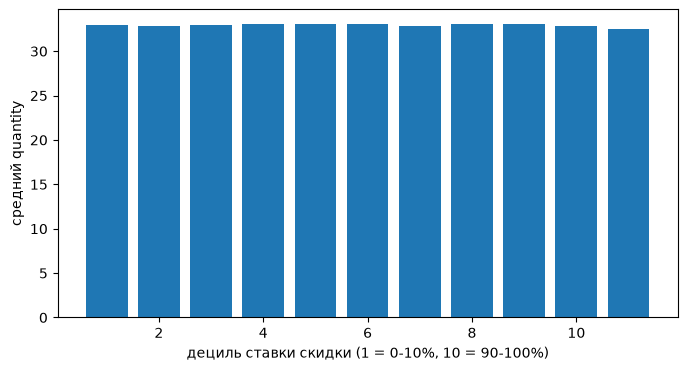

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(elasticity["decile"], elasticity["avg_quantity"])
ax.set_xlabel("дециль ставки скидки (1 = 0-10%, 10 = 90-100%)")
ax.set_ylabel("средний quantity")
plt.show()

In [11]:
corr = pd.read_sql(
    f"""
    select corr(discount_per_item::numeric / nullif(price_per_item, 0), quantity) as pearson_corr
    from staging.stg_sales
    where source_date >= '{YEAR_START}' and source_date < '{YEAR_END}' and price_per_item > 0
    """,
    engine,
)
corr

,pearson_corr
0,0.000403


## Итог

Скидка не двигает объём продаж: корреляция с `quantity` — 0.0004 средний `quantity` по децилям ставки скидки — плоская линия около 33 в каждом дециле. 

Прямое следствие для ассортиментной политики: снижать глубину скидки на товарах со стабильным спросом (сегменты X и Y, ниже) можно без риска потерять объём, это возврат маржи, а не гипотеза которую ещё нужно проверять. Наращивать скидку ради роста продаж в этих данных не сработает промобюджет на это уйдёт без эффекта на объём.

Классическая логика ABC/XYZ (усилить AX пересмотреть CZ, вывести откровенных аутсайдеров) работает здесь только частично. У выручки нет концентрации: 53% товаров нужно, чтобы набрать 80% выручки, а не классические +-20%, явных лидеров или аутсайдеров по деньгам почти нет Весь ассортимент вносит сопоставимый вклад. 

Стабильность спроса (XYZ на кварталах, месячная группировка для этого слишком мелкая) тоже не связана с уровнем выручки: доля X почти одинаковая что в группе A что в B что в C (0.88-0.94%). Сегмент CZ (низкая выручка и нестабильный спрос одновременно) — 10 427 товаров, это единственная комбинация, для которой в данных есть содержательное основание пересмотреть присутствие в ассортименте, остальные комбинации сегментов такого сигнала не дают.

Два ограничения которые стоит подсветить: В данных нет себестоимости, есть только цена и скидка, реальную маржинальность посчитать нельзя, только выручку, рекомендации по марже без учёта себестоимости были бы гаданием. И нет категорий или названий товаров, весь анализ - на уровне отдельных `product_id`, это ограничивает выводы уровнем категорий. 

Первый практический шаг к более содержательному ABC/XYZ здесь - в данных: завести учёт себестоимости хотя бы по укрупнённым группам и завести сами товарные категории.